In [29]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


from metastable.state import FixedPointMap
from metastable.eom import EOM, Params
from metastable.manifold_inverses import calculate_manifold_inverses
from metastable.incoming_quantum_vector import extend_to_keldysh_state


fixed_point_map = FixedPointMap.load("/home/paul/Projects/keldysh/metastable/scratch/map.npz")
epsilon_idx = 50
kappa_idx = 25
params = Params(
    epsilon=fixed_point_map.epsilon_linspace[epsilon_idx],
    kappa=fixed_point_map.kappa_linspace[kappa_idx],
    delta=fixed_point_map.delta,
    chi=fixed_point_map.chi,
)
eom = EOM(params=params)
classical_saddle_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 0]
classical_focus_point = fixed_point_map.fixed_points[epsilon_idx, kappa_idx, 1]
print(fixed_point_map.epsilon_linspace.shape)
print(fixed_point_map.kappa_linspace.shape)
print(params)
print(classical_saddle_point, classical_focus_point)


keldysh_saddle_point = extend_to_keldysh_state(classical_saddle_point)
keldysh_focus_point = extend_to_keldysh_state(classical_focus_point)
_, saddle_point_unstable_manifold_inverse = calculate_manifold_inverses(
    keldysh_saddle_point, params
)
focus_point_stable_manifold_inverse, _ = calculate_manifold_inverses(
    keldysh_focus_point, params
)
focus_point_bc_vectors = focus_point_stable_manifold_inverse + np.dot(np.array([[0,1],[-1,0]]),focus_point_stable_manifold_inverse)

def boundary_condition_func(ya, yb):
    return np.hstack(
        [
            np.abs(np.dot(focus_point_bc_vectors, ya - keldysh_focus_point)),
            np.abs(np.dot(saddle_point_unstable_manifold_inverse, yb - keldysh_saddle_point)),
        ]
    )

(51,)
(31,)
epsilon=10.0 delta=7.8 chi=-0.1 kappa=1.25
[-8.23221493  7.99662905] [-10.82962803  -7.48286076]


In [35]:
jacobian = eom.jacobian_func(keldysh_saddle_point)
eigenvalues, eigenvectors = np.linalg.eig(jacobian)
delta = 1e-9
y0 = keldysh_saddle_point + delta*eigenvectors[:,2]
ivp_wrapper = lambda x, y: -eom.y_dot_func(y)

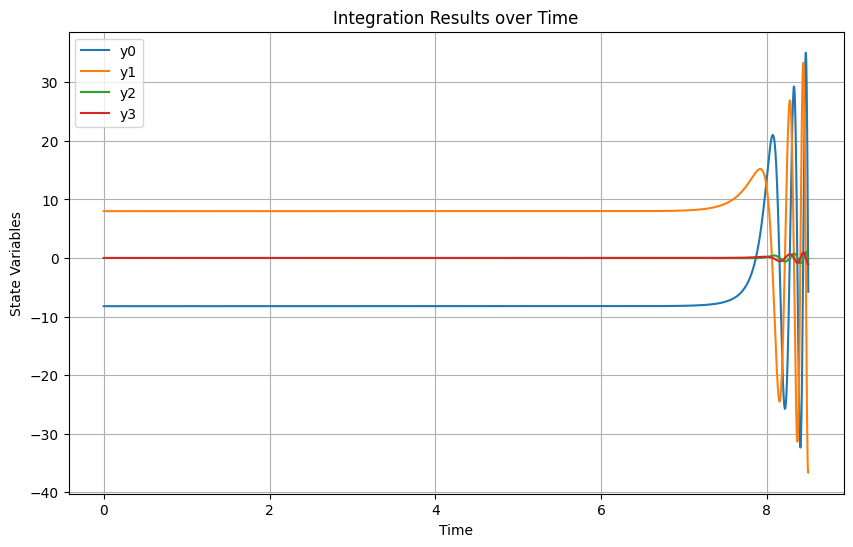

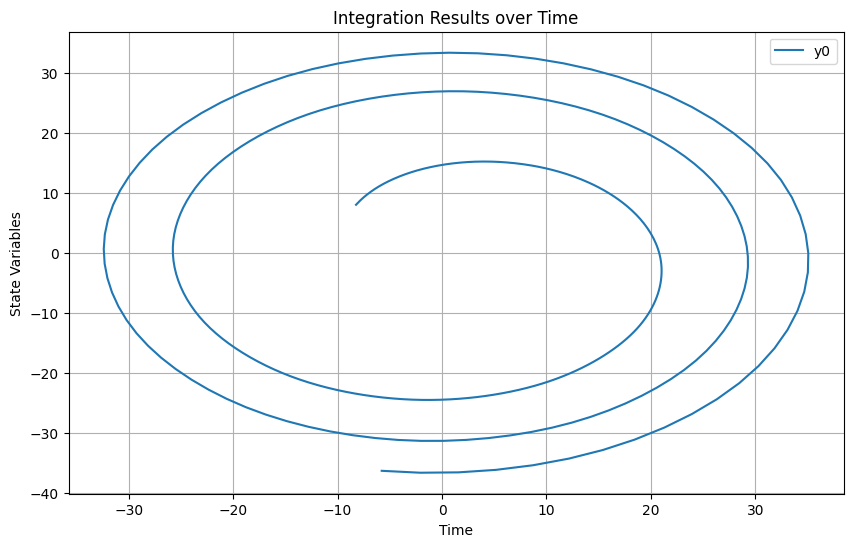

In [36]:
t1 = 8.5

res_ivp = scipy.integrate.solve_ivp(
    ivp_wrapper,
    t_span=(0.0, t1),
    y0=y0,
    method='RK45',  # Default method, change if needed
    t_eval=np.linspace(0.0, t1, 5000)  # Optional: for smoother plot results
)

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(res_ivp.t, res_ivp.y.T)
plt.title('Integration Results over Time')
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.grid(True)
plt.legend(['y' + str(i) for i in range(res_ivp.y.shape[0])])
plt.show()

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(res_ivp.y[0,:], res_ivp.y[1,:])
plt.title('Integration Results over Time')
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.grid(True)
plt.legend(['y' + str(i) for i in range(res_ivp.y.shape[0])])
plt.show()

In [28]:
bvp_t_guess = res_ivp.t
bvp_y_guess = res_ivp.y[:,::-1]
bvp_y_guess[:,0] = keldysh_focus_point

bvp_wrapper = lambda x, y: eom.y_dot_func(y)
jac_wrapper = lambda x, y: eom.jacobian_func(y)
res_final = scipy.integrate.solve_bvp(
    bvp_wrapper, boundary_condition_func, res_ivp.t, res_ivp.y[:,::-1], tol=3e-5, max_nodes=1_000_000, verbose=2
)


import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,1,figsize=(5, 5))
t_plot = np.linspace(0, res_final.x[-1], 50001)
y0_plot = res_final.sol(t_plot)[0]
y1_plot = res_final.sol(t_plot)[1]
axes.plot(y0_plot,y1_plot)
axes.scatter([keldysh_saddle_point[0]],[keldysh_saddle_point[1]])
axes.scatter([keldysh_focus_point[0]],[keldysh_focus_point[1]])
plt.show()

# Plotting results
plt.figure(figsize=(10, 6))
plt.plot(res_final.x, res_final.y.T)
plt.title('Integration Results over Time')
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.grid(True)
plt.legend(['y' + str(i) for i in range(res_final.y.shape[0])])
plt.show()

   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          1.09e+01       1.30e+00         5000            373      
       2          1.31e+01       1.00e+00         5373           1024      
       3          1.54e+01       7.74e-01         6397           2863      
       4          1.28e+01       5.98e-01         9260           8108      
       5          1.66e+01       4.62e-01         17368          23112     
       6          1.29e+00       1.09e-08         40480          50436     
       7          1.80e-01       1.55e-02         90916          1208      
       8          2.44e-01       1.20e-02         92124          1225      
       9          5.03e-01       9.26e-03         93349          1729      
      10          2.52e+00       7.15e-03         95078          3078      
      11          3.73e-01       5.52e-03         98156          5448      
      12          8.40e-01       4.27e-03        103604          9786      
      13    

KeyboardInterrupt: 

In [ ]:
res_final